<a href="https://colab.research.google.com/github/Rahmat-Fitrah/Projek-kelompok-9-big-data/blob/main/Tugas_kelompok_9_bigdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 5 Data Teratas ---
             Job_Title  Average_Salary  Years_Experience Education_Level  \
0       Security Guard           45795                28        Master's   
1   Research Scientist          133355                20             PhD   
2  Construction Worker          146216                 2     High School   
3    Software Engineer          136530                13             PhD   
4    Financial Analyst           70397                22     High School   

   AI_Exposure_Index  Tech_Growth_Factor  Automation_Probability_2030  \
0               0.18                1.28                         0.85   
1               0.62                1.11                         0.05   
2               0.86                1.18                         0.81   
3               0.39                0.68                         0.60   
4               0.52                1.46                         0.64   

  Risk_Category  Skill_1  Skill_2  Skill_3  Skill_4  Skill_5  Skill_6  \
0       

/tmp/ipykernel_5207/2788387693.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk_Category', palette='viridis')


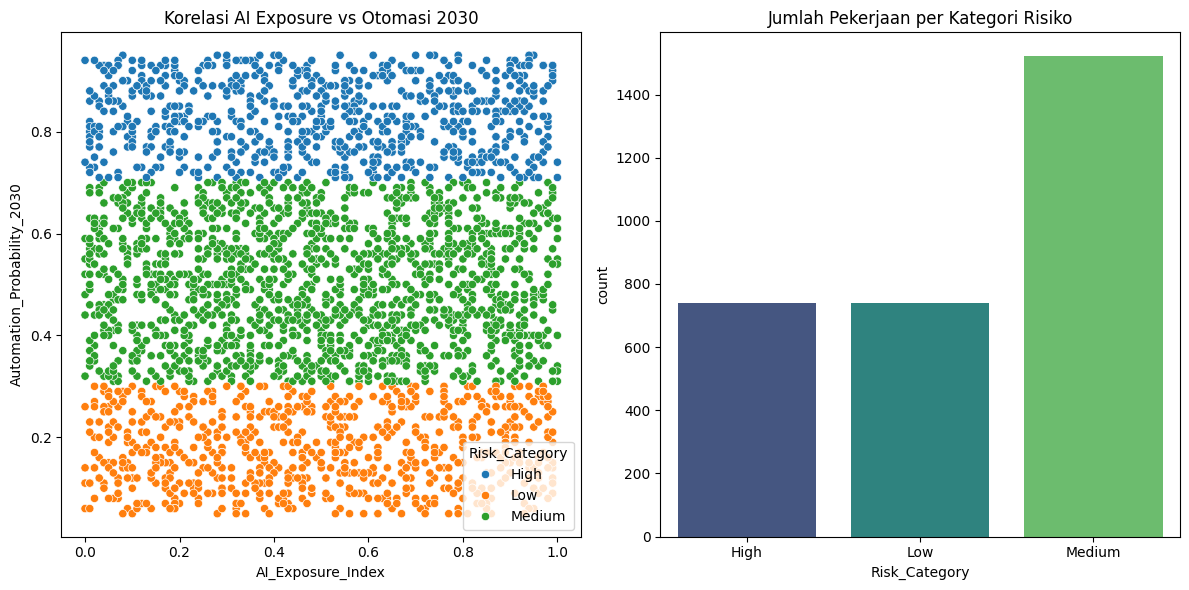


--- Rekomendasi Pekerjaan Aman (Gaji Tinggi, Otomasi Rendah) ---
             Job_Title  Average_Salary  Automation_Probability_2030
1   Research Scientist          133355                         0.05
17             Teacher          103744                         0.28
19              Doctor          108069                         0.15
24         AI Engineer          125435                         0.17
30             Teacher          114076                         0.19


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca Data
# Menggunakan sep=';' karena file CSV kamu menggunakan titik koma sebagai pemisah
df = pd.read_csv('AI_Impact_on_Jobs_2030.csv', sep=';')

# 2. Inspeksi Awal
print("--- 5 Data Teratas ---")
print(df.head())
print("\n--- Info Data ---")
print(df.info())

# 3. Analisis Statistik Sederhana
# Melihat rata-rata probabilitas otomasi berdasarkan tingkat pendidikan
education_analysis = df.groupby('Education_Level')['Automation_Probability_2030'].mean().sort_values()
print("\n--- Rata-rata Probabilitas Otomasi per Tingkat Pendidikan ---")
print(education_analysis)

# 4. Visualisasi
plt.figure(figsize=(12, 6))

# Plot A: Hubungan AI Exposure dengan Probabilitas Otomasi
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='AI_Exposure_Index', y='Automation_Probability_2030', hue='Risk_Category')
plt.title('Korelasi AI Exposure vs Otomasi 2030')

# Plot B: Distribusi Risk Category
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Risk_Category', palette='viridis')
plt.title('Jumlah Pekerjaan per Kategori Risiko')

plt.tight_layout()
plt.show()

# 5. Mencari Top 5 Pekerjaan dengan Gaji Tertinggi namun Risiko Otomasi Rendah
high_value_jobs = df[(df['Automation_Probability_2030'] < 0.3) & (df['Average_Salary'] > 100000)]
print("\n--- Rekomendasi Pekerjaan Aman (Gaji Tinggi, Otomasi Rendah) ---")
print(high_value_jobs[['Job_Title', 'Average_Salary', 'Automation_Probability_2030']].head())

/tmp/ipykernel_5207/492527324.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Education_Level', y='Average_Salary', palette='viridis')
/tmp/ipykernel_5207/492527324.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Risk_Category', y='Average_Salary', palette='Set2')
/tmp/ipykernel_5207/492527324.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Education_Level', y='Tech_Growth_Factor', palette='muted')


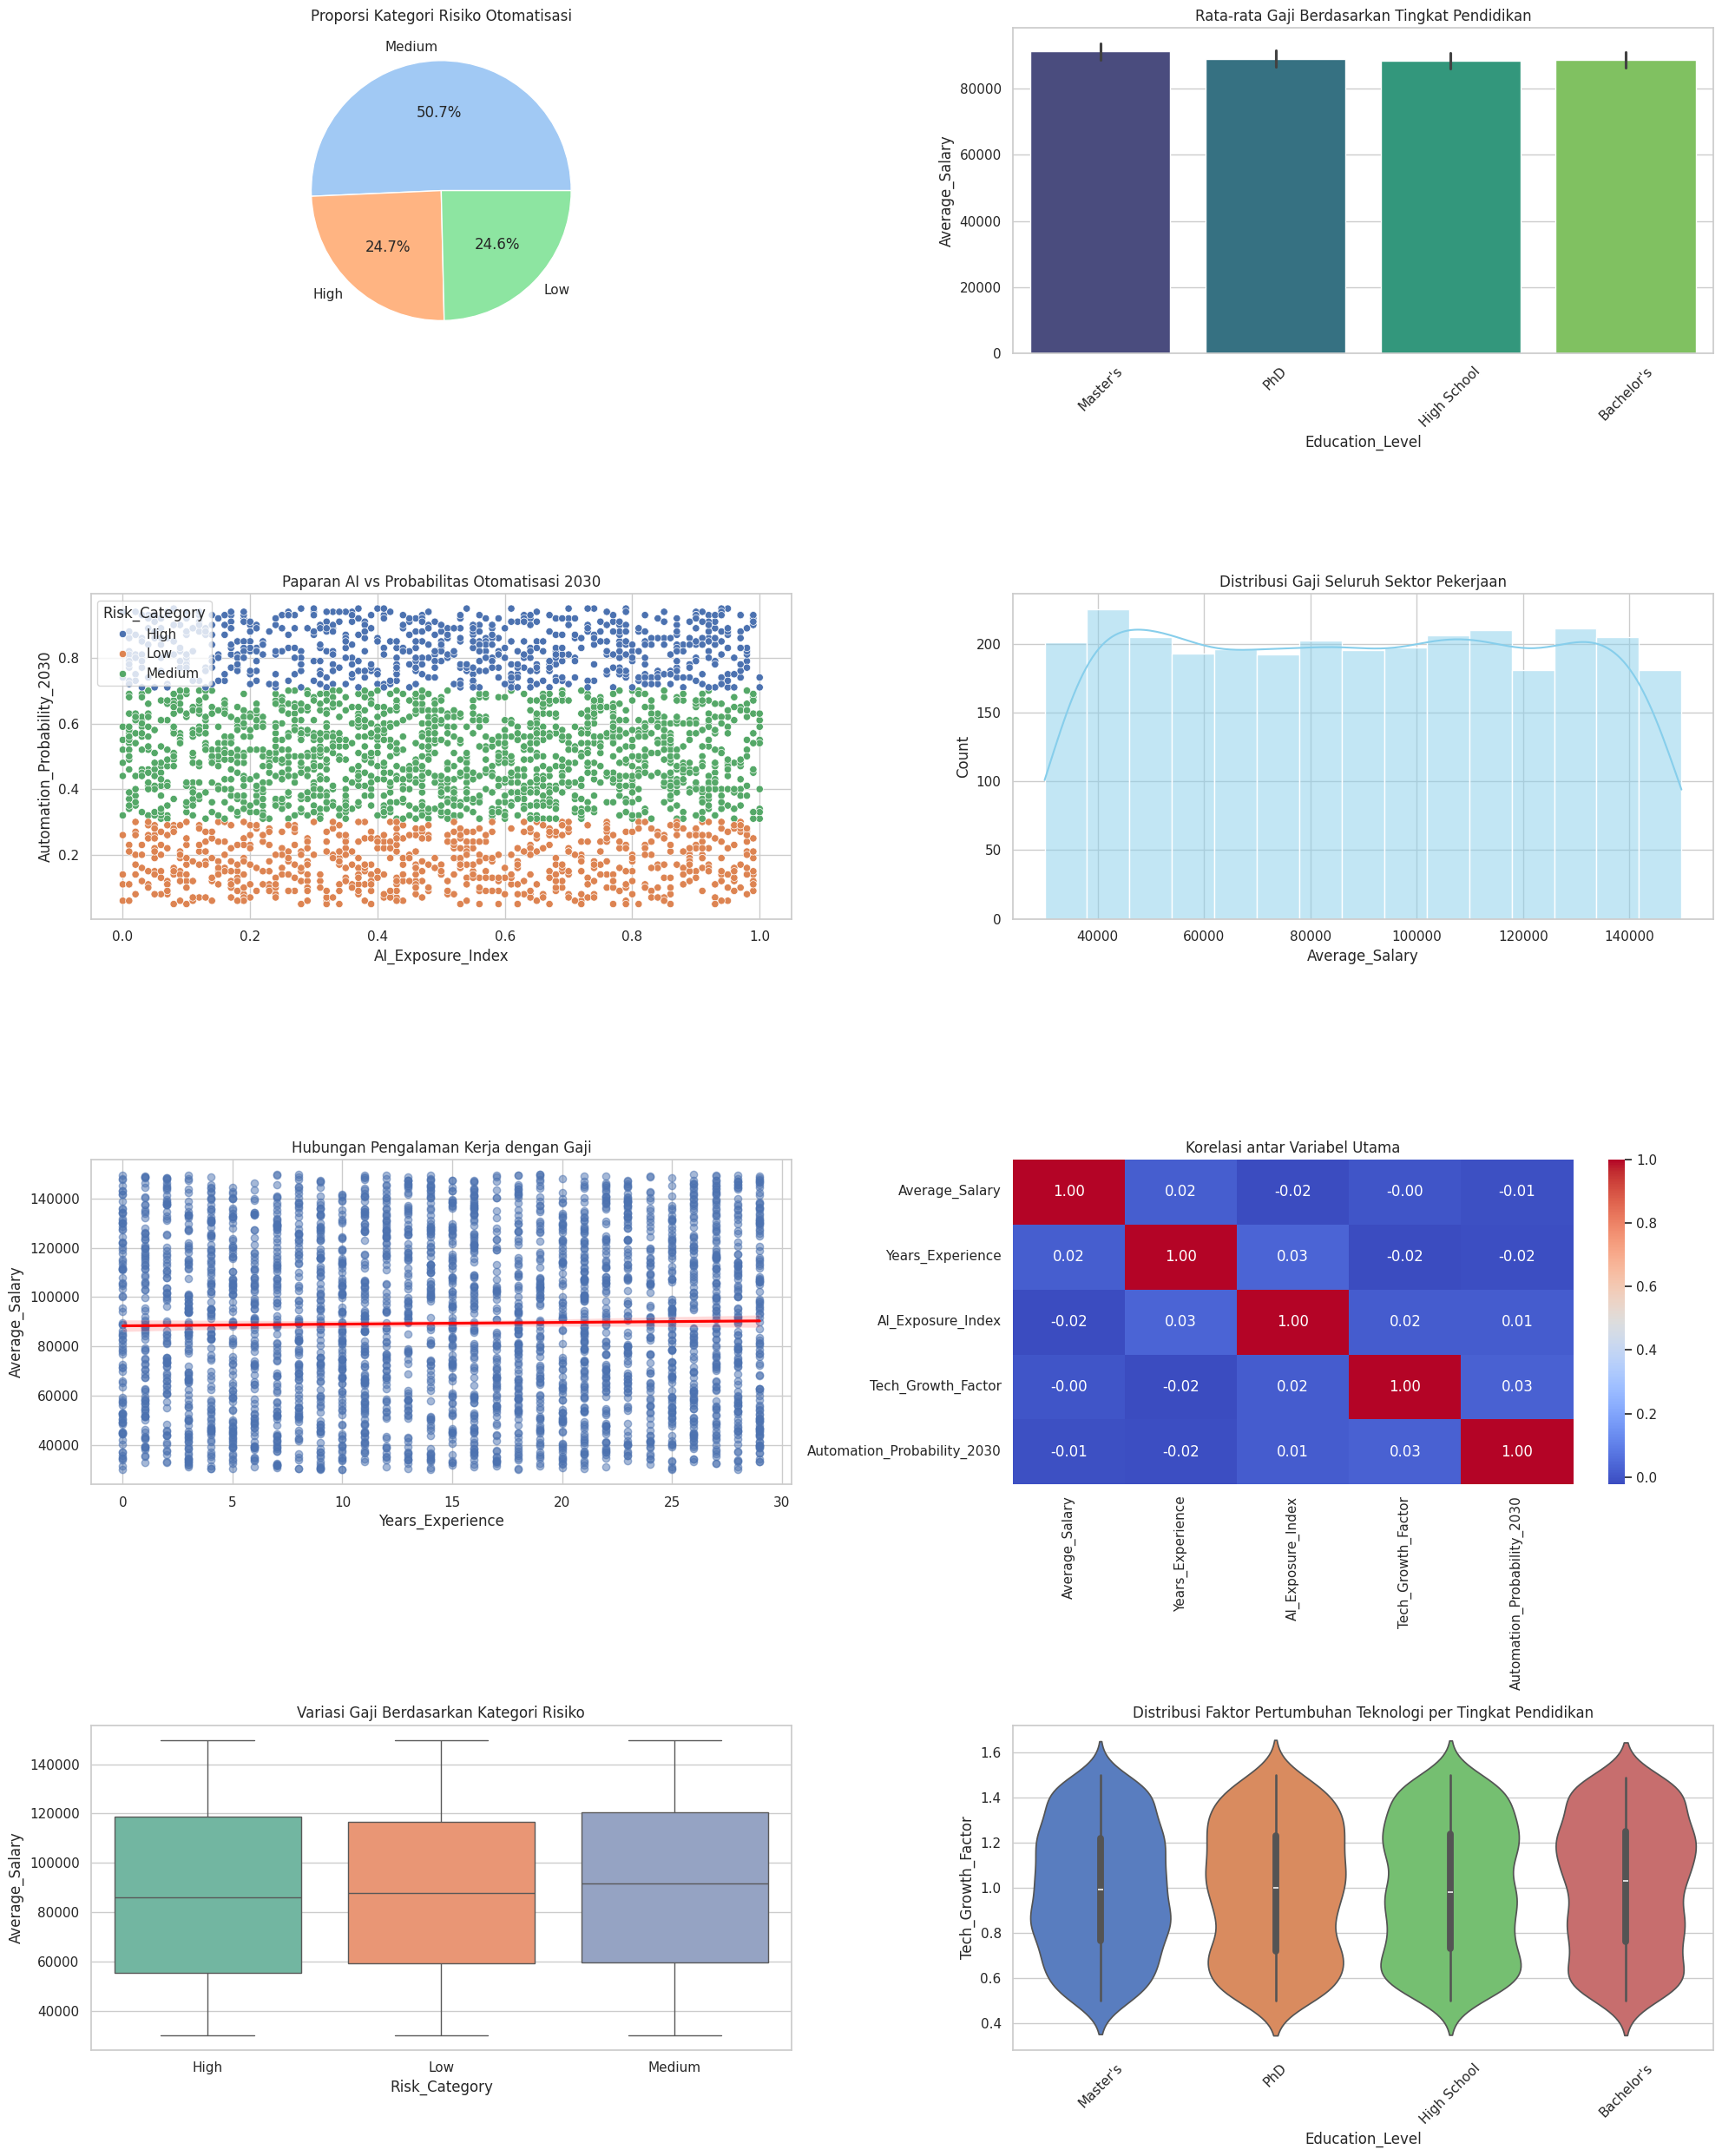

In [2]:

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 25))

# 1. Distribusi Risk Category (Pie Chart)
plt.subplot(4, 2, 1)
df['Risk_Category'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Proporsi Kategori Risiko Otomatisasi')
plt.ylabel('')

# 2. Rata-rata Gaji berdasarkan Tingkat Pendidikan (Bar Plot)
plt.subplot(4, 2, 2)
sns.barplot(data=df, x='Education_Level', y='Average_Salary', palette='viridis')
plt.title('Rata-rata Gaji Berdasarkan Tingkat Pendidikan')
plt.xticks(rotation=45)

# 3. Hubungan AI Exposure Index vs Automation Probability (Scatter Plot)
plt.subplot(4, 2, 3)
sns.scatterplot(data=df, x='AI_Exposure_Index', y='Automation_Probability_2030', hue='Risk_Category')
plt.title('Paparan AI vs Probabilitas Otomatisasi 2030')

# 4. Distribusi Gaji (Histogram)
plt.subplot(4, 2, 4)
sns.histplot(df['Average_Salary'], kde=True, color='skyblue')
plt.title('Distribusi Gaji Seluruh Sektor Pekerjaan')

# 5. Pengaruh Pengalaman Kerja terhadap Gaji (Regplot)
plt.subplot(4, 2, 5)
sns.regplot(data=df, x='Years_Experience', y='Average_Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Hubungan Pengalaman Kerja dengan Gaji')

# 6. Heatmap Korelasi antar Variabel Numerik (Heatmap)
plt.subplot(4, 2, 6)
numeric_cols = df[['Average_Salary', 'Years_Experience', 'AI_Exposure_Index', 'Tech_Growth_Factor', 'Automation_Probability_2030']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korelasi antar Variabel Utama')

# 7. Boxplot Gaji berdasarkan Risk Category (Box Plot)
plt.subplot(4, 2, 7)
sns.boxplot(data=df, x='Risk_Category', y='Average_Salary', palette='Set2')
plt.title('Variasi Gaji Berdasarkan Kategori Risiko')

# 8. Tech Growth Factor berdasarkan Pendidikan (Violin Plot)
plt.subplot(4, 2, 8)
sns.violinplot(data=df, x='Education_Level', y='Tech_Growth_Factor', palette='muted')
plt.title('Distribusi Faktor Pertumbuhan Teknologi per Tingkat Pendidikan')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()